In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('data/project2.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.drop(columns=['customerID'], inplace=True)

# Data Exploration

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
numcols = df.select_dtypes(include=np.number).columns.tolist()
catcols = df.select_dtypes(exclude=np.number).columns.tolist()
print("Numerical Columns:", numcols)
print("Categorical Columns:", catcols)

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## Outlier Detection


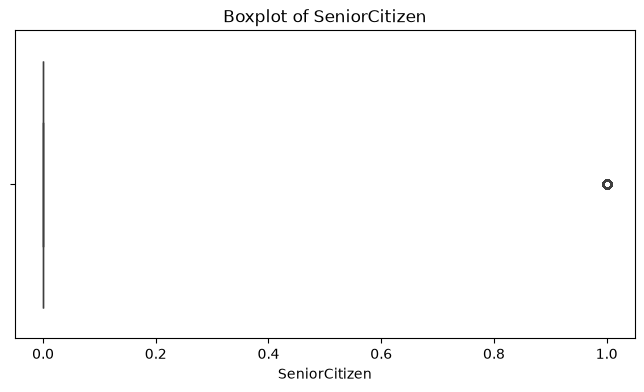

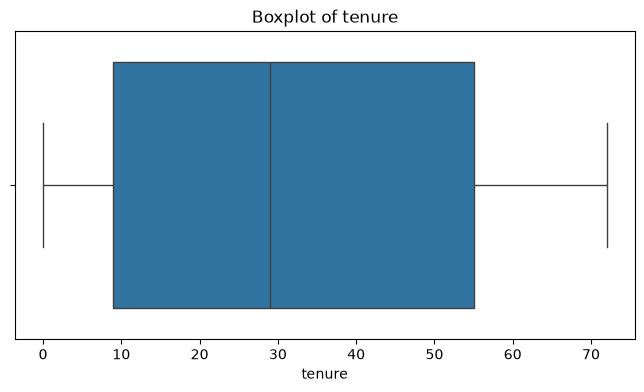

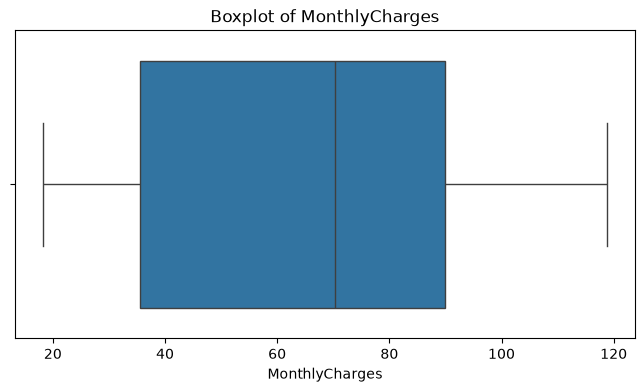

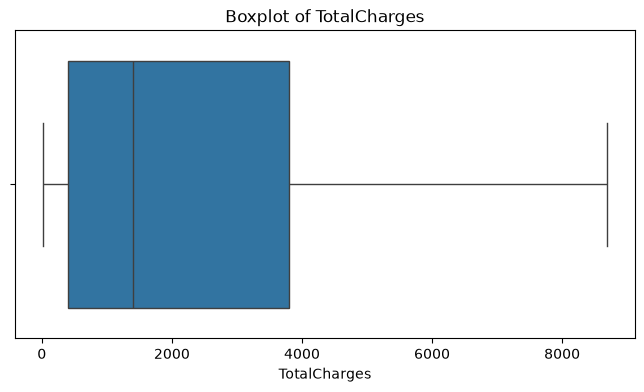

In [7]:
##boxplot
for col in numcols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### No Outliers Detected from Above Boxplot



## Distribution of Data

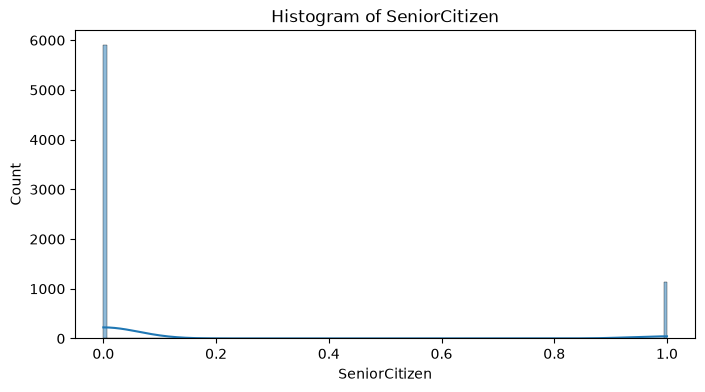

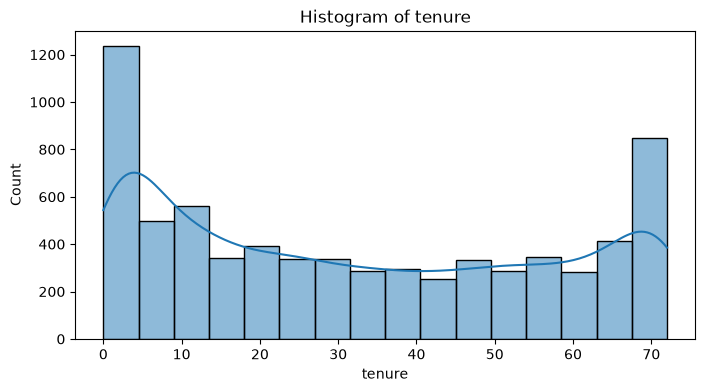

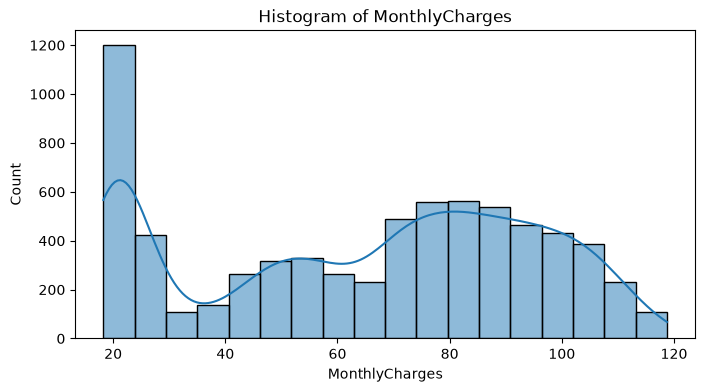

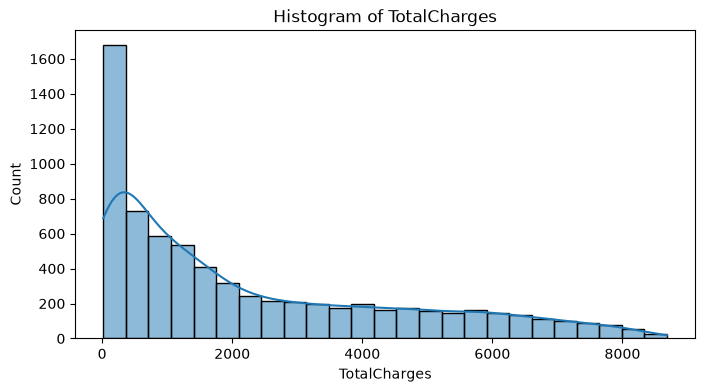

In [8]:
#histplot
for col in numcols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

## Countplot


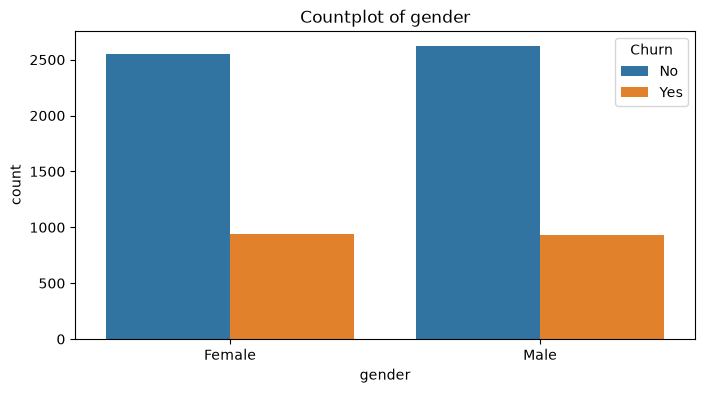

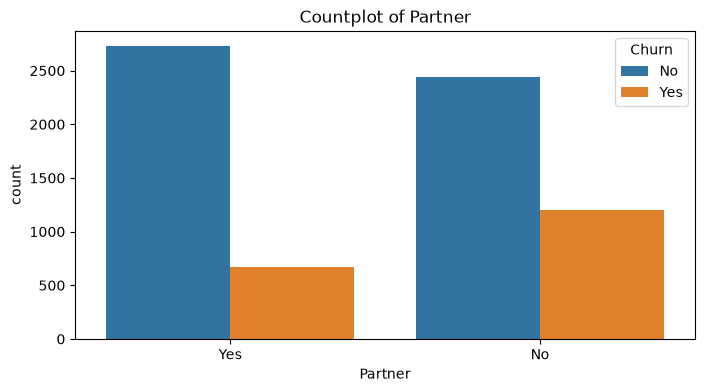

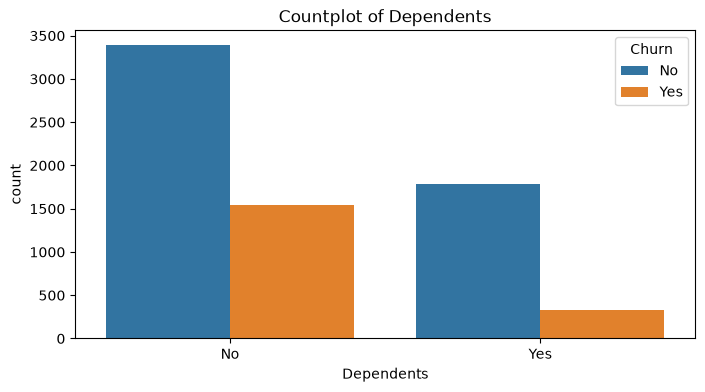

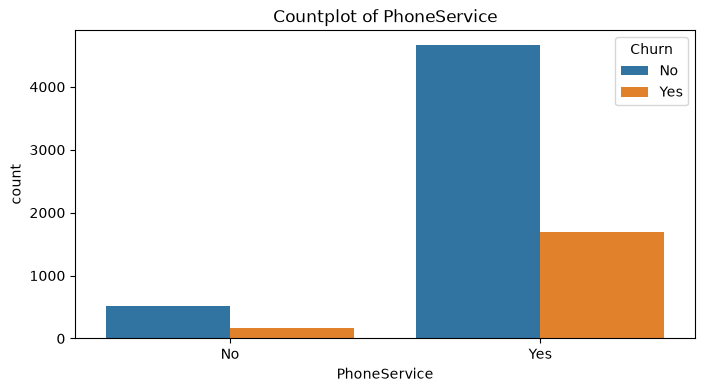

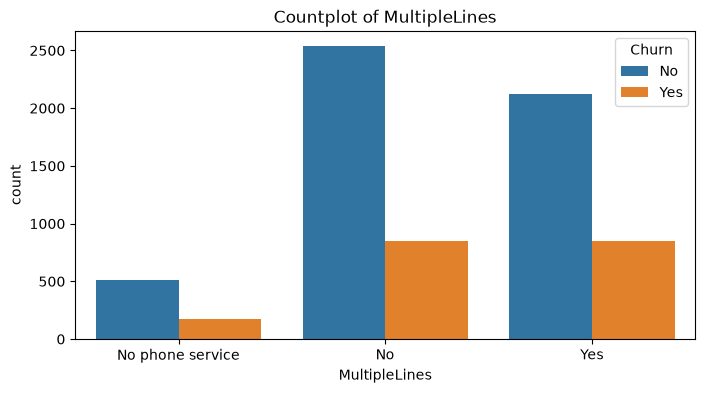

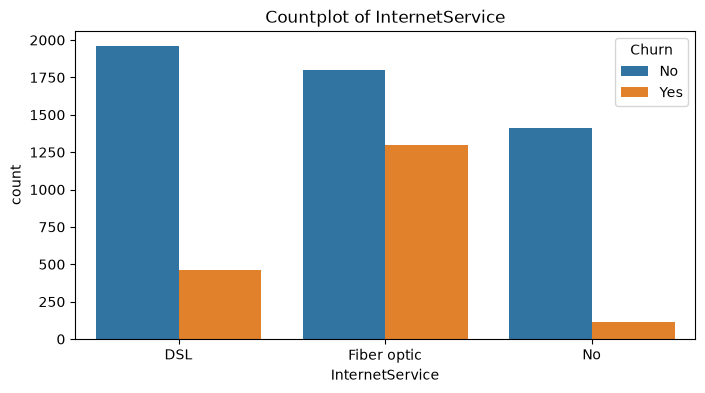

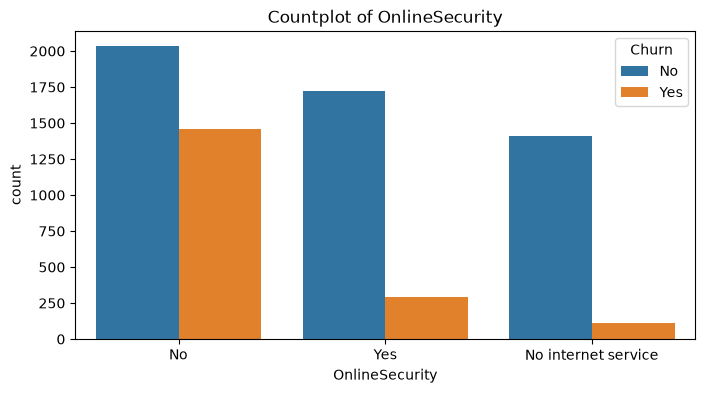

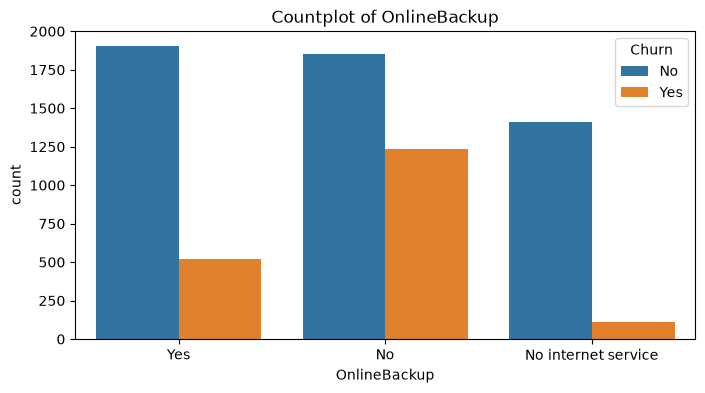

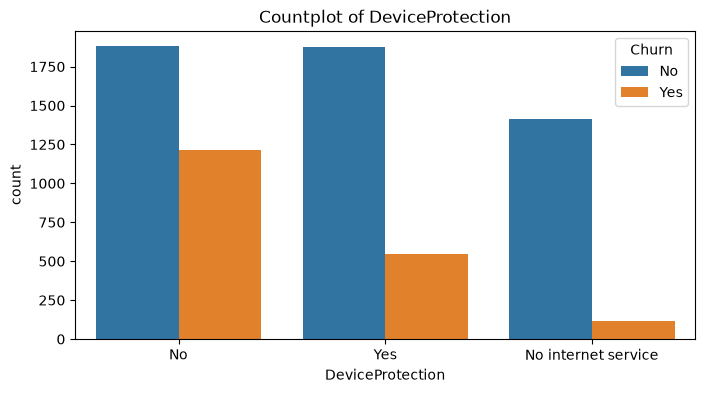

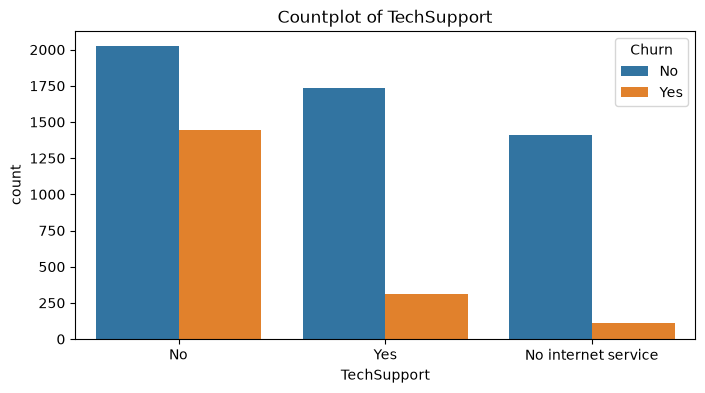

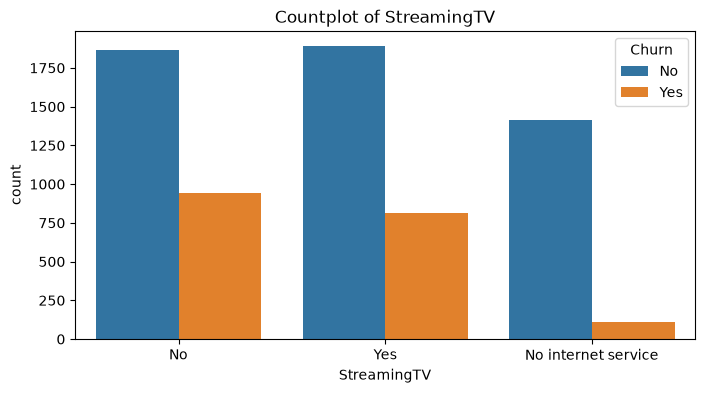

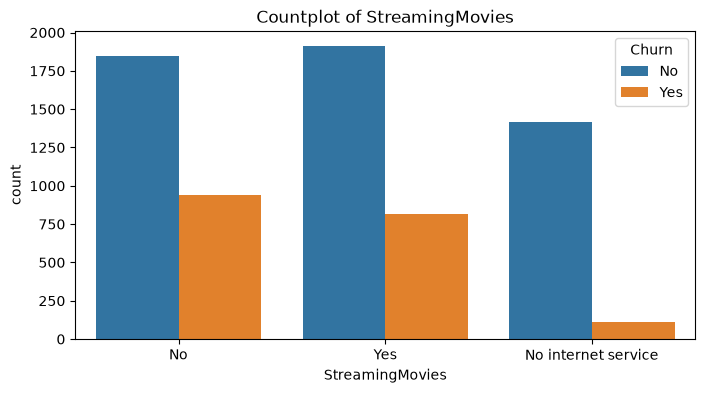

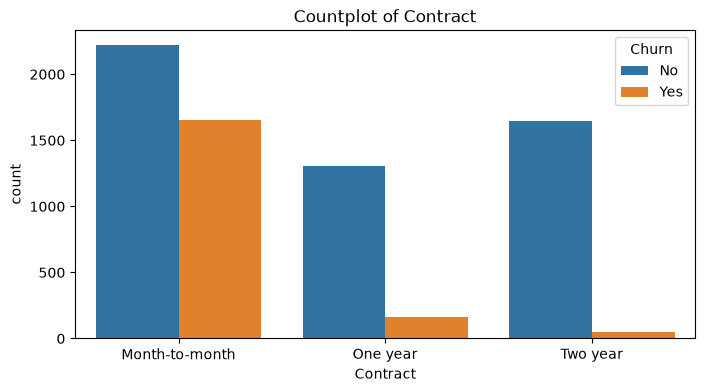

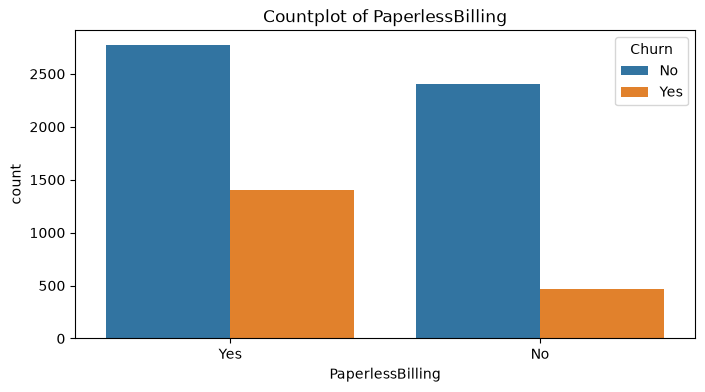

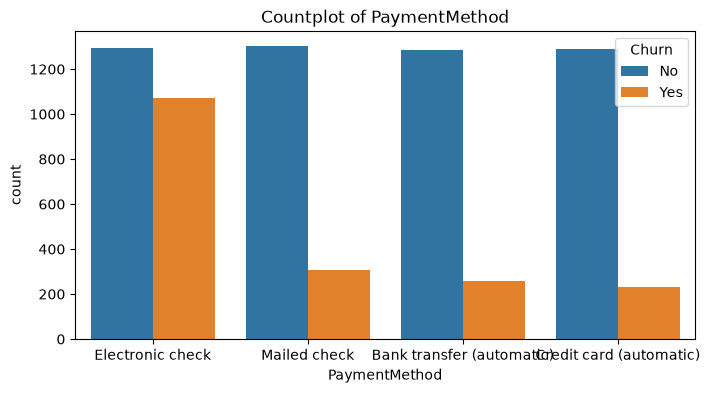

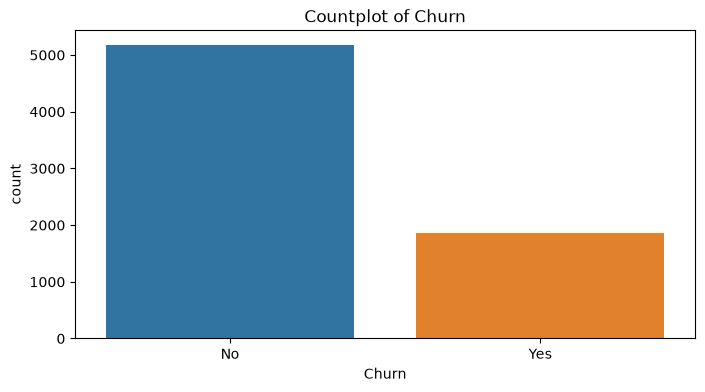

In [9]:
for col in catcols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col], hue=df['Churn'])
    plt.title(f'Countplot of {col}')
    plt.show()

## Checking for Null Values

In [10]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df.dropna(inplace=True)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Dropping the Null Values since it is a minor loss of data

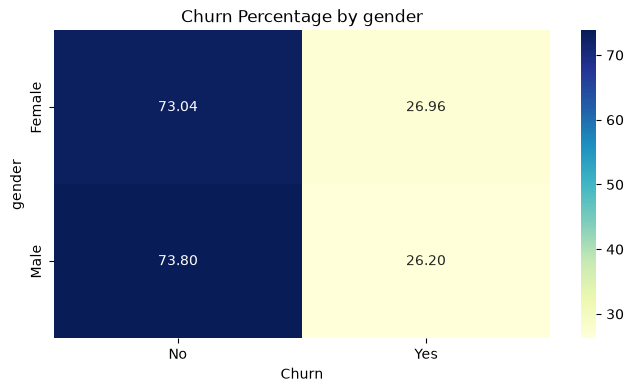

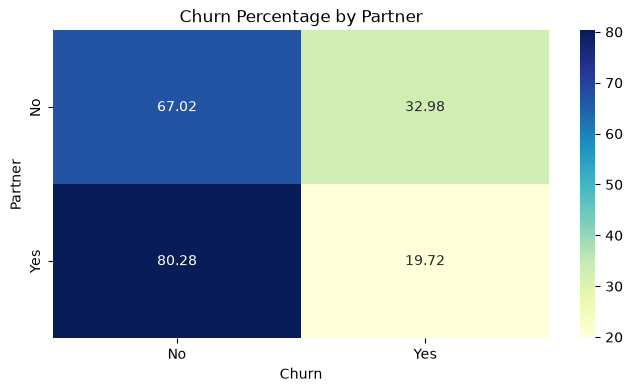

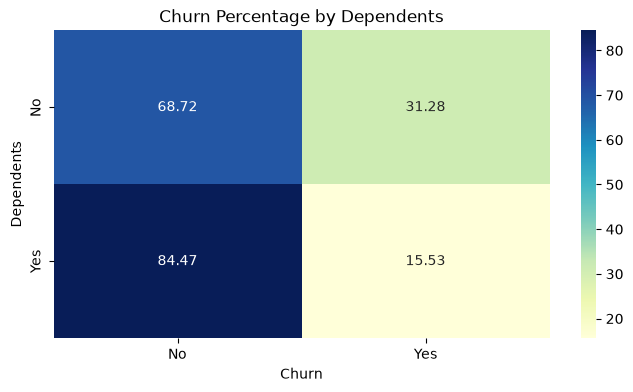

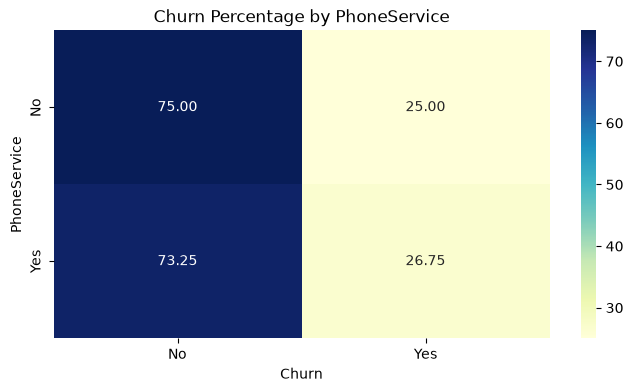

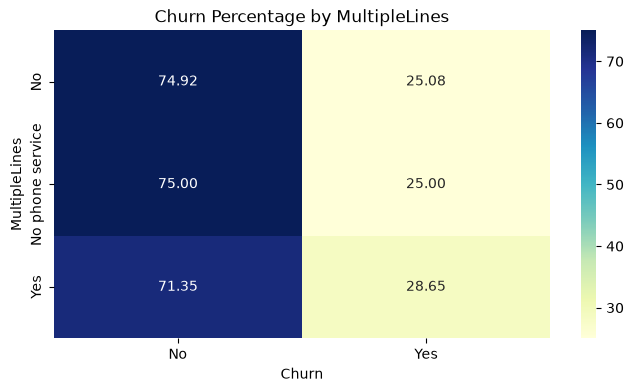

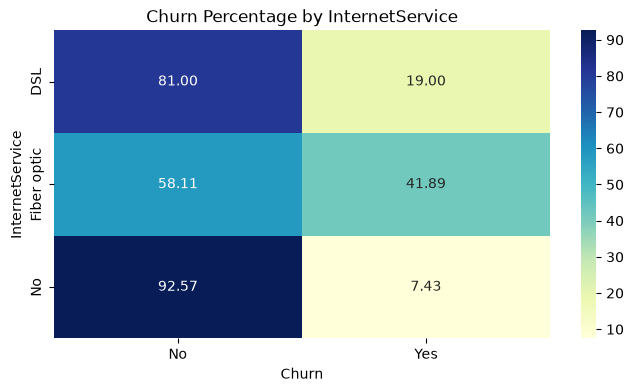

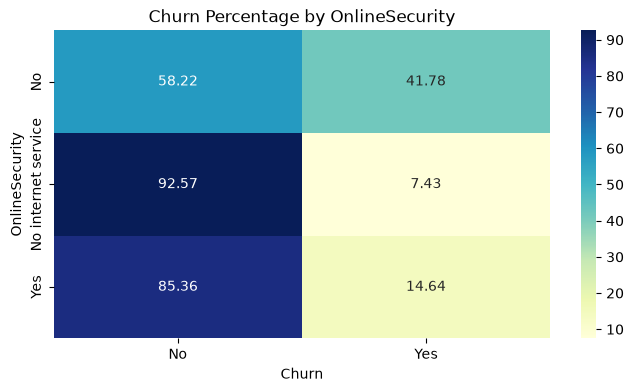

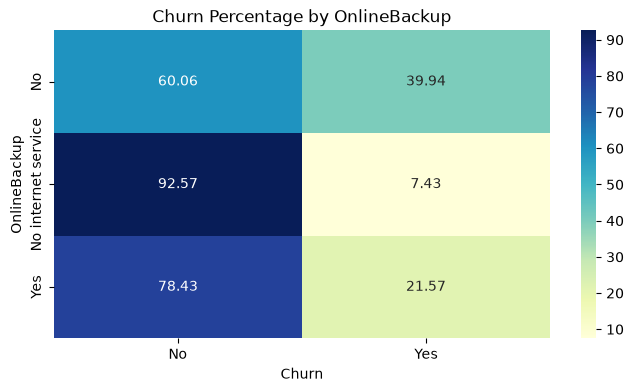

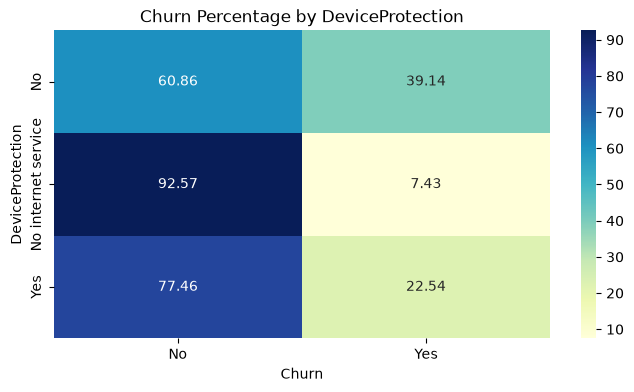

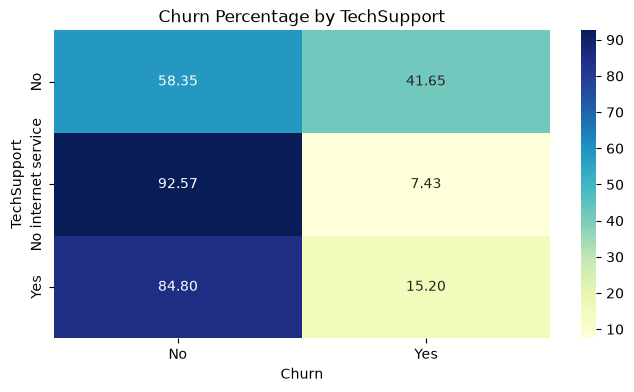

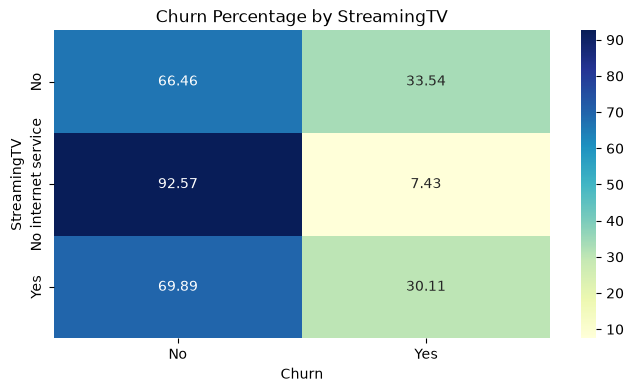

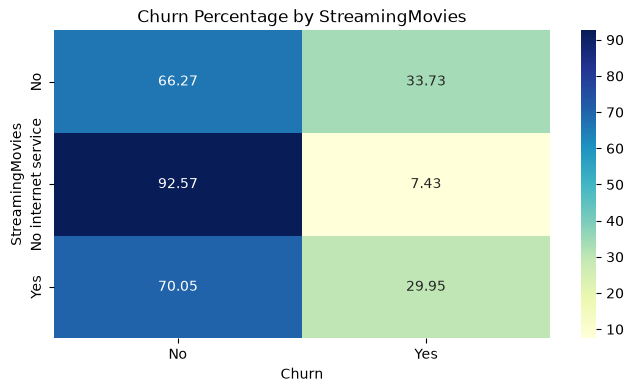

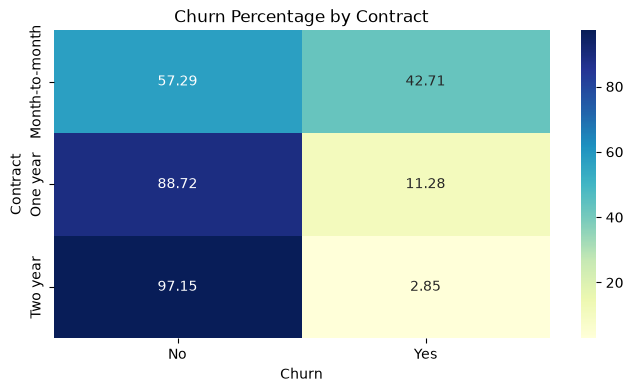

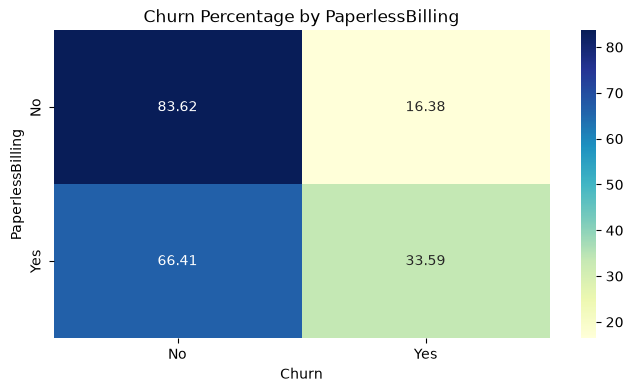

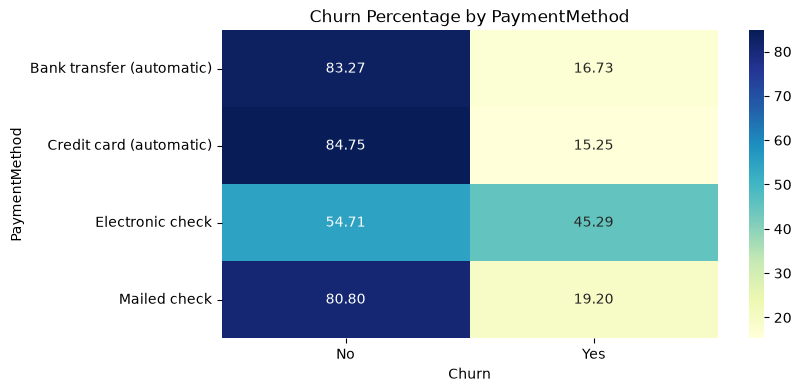

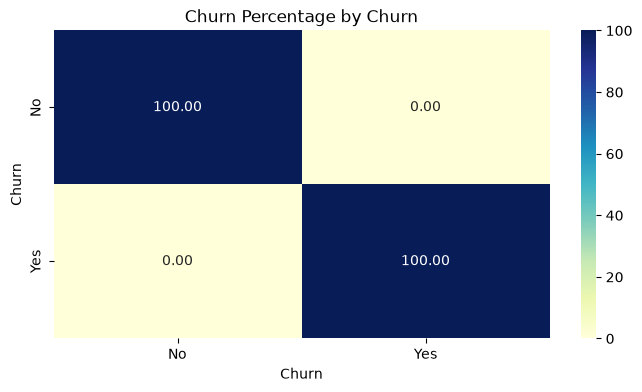

In [12]:
#crosstab heatmap
for col in catcols:
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    plt.figure(figsize=(8, 4))
    sns.heatmap(crosstab, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f'Churn Percentage by {col}')
    plt.ylabel(col)
    plt.xlabel('Churn')
    plt.show()
    
   

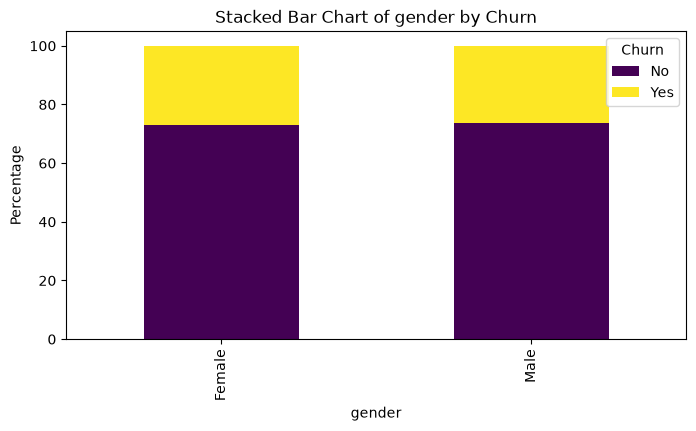

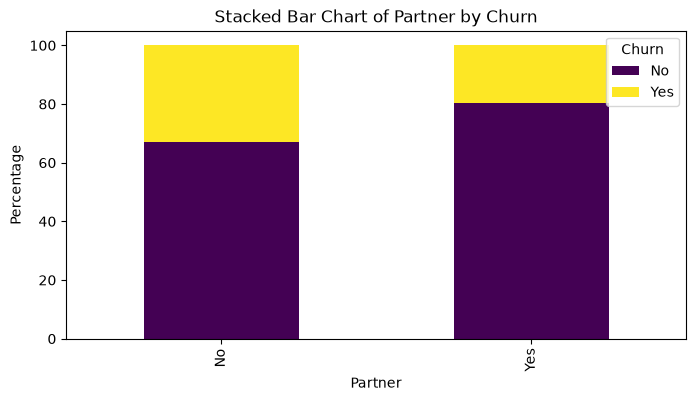

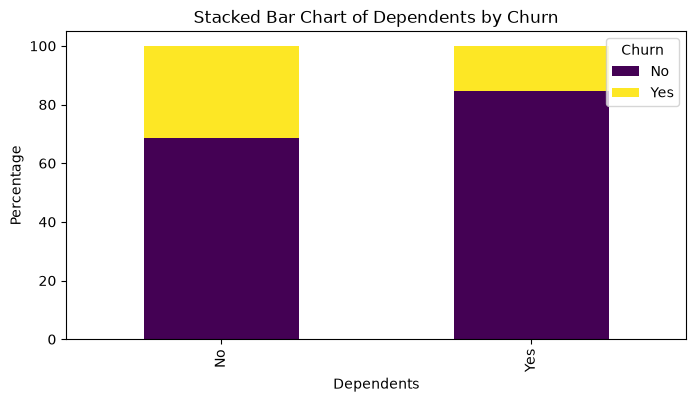

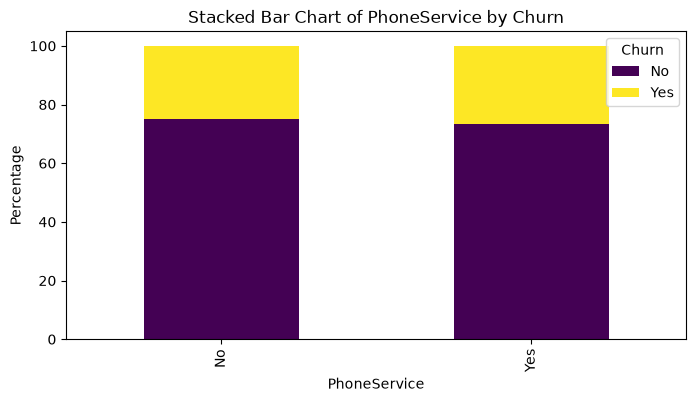

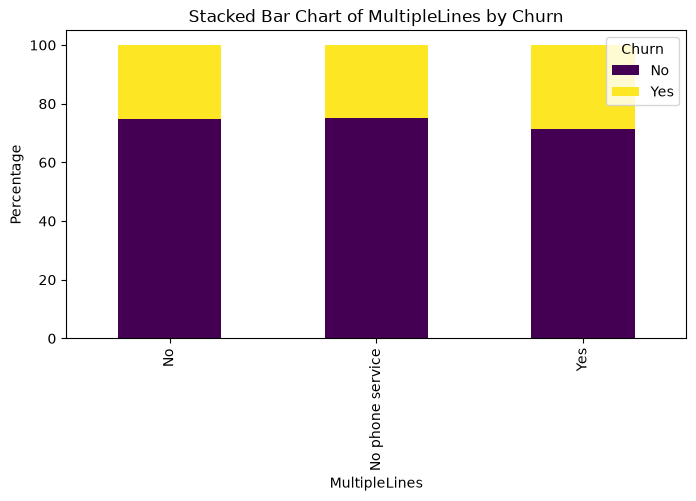

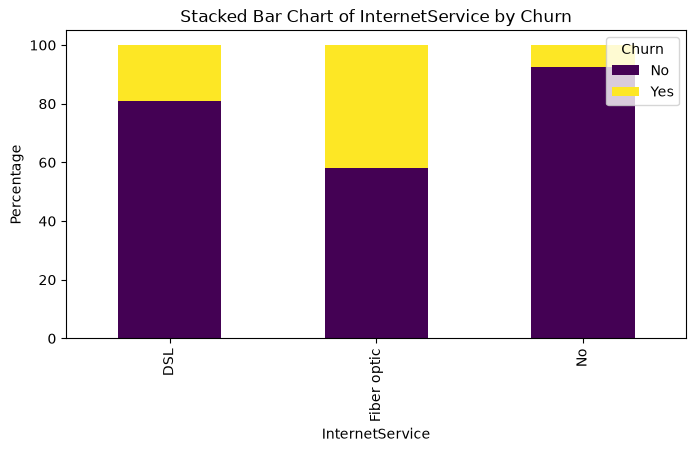

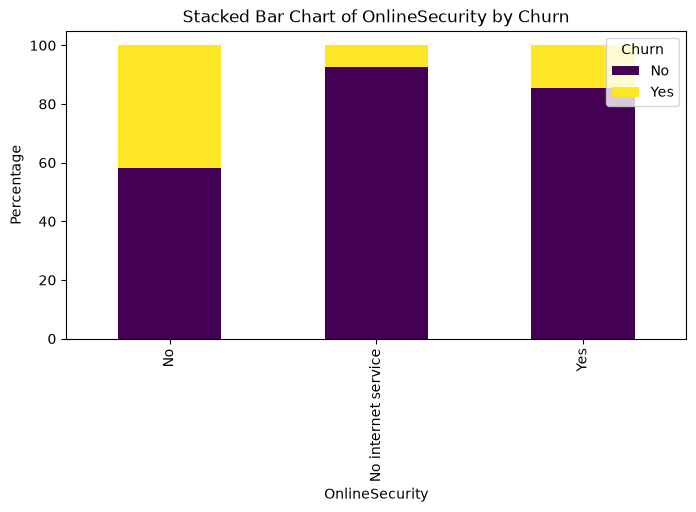

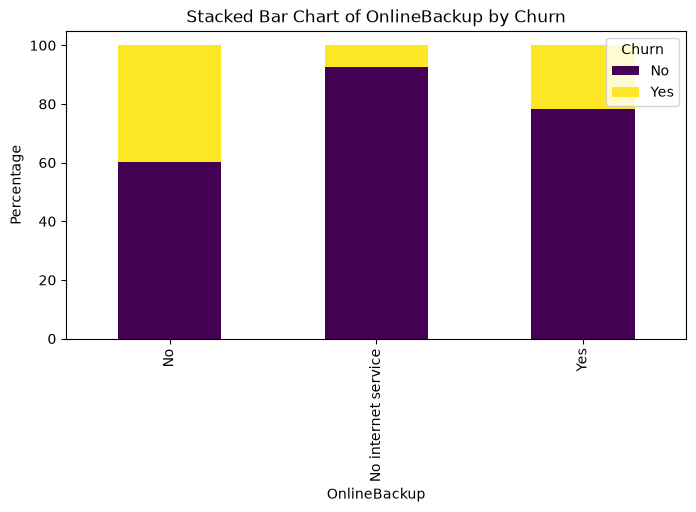

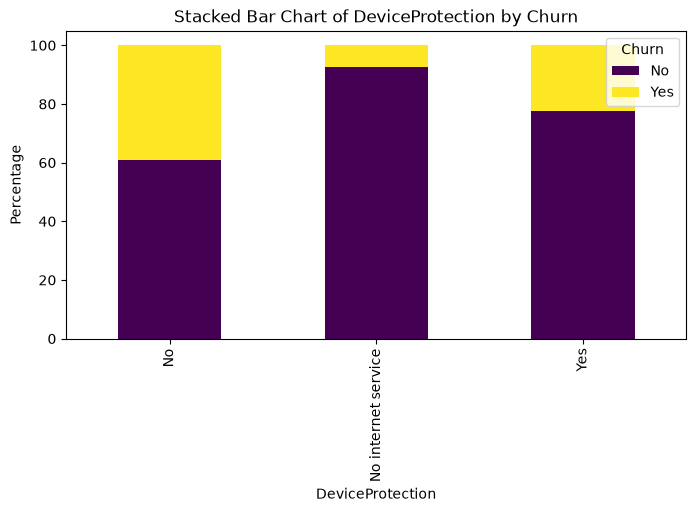

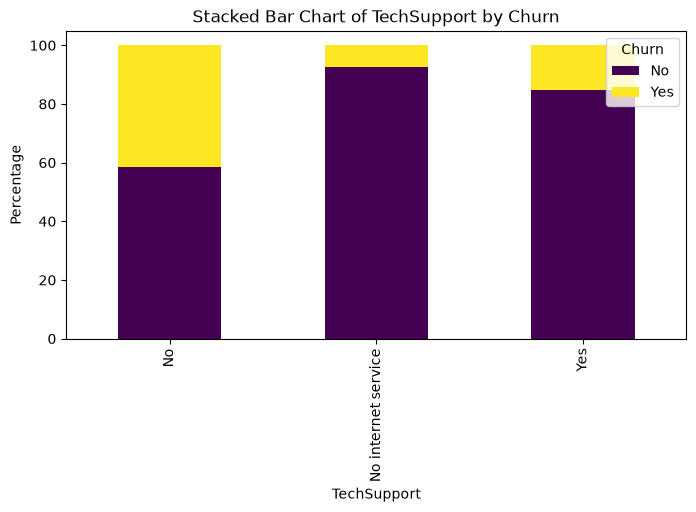

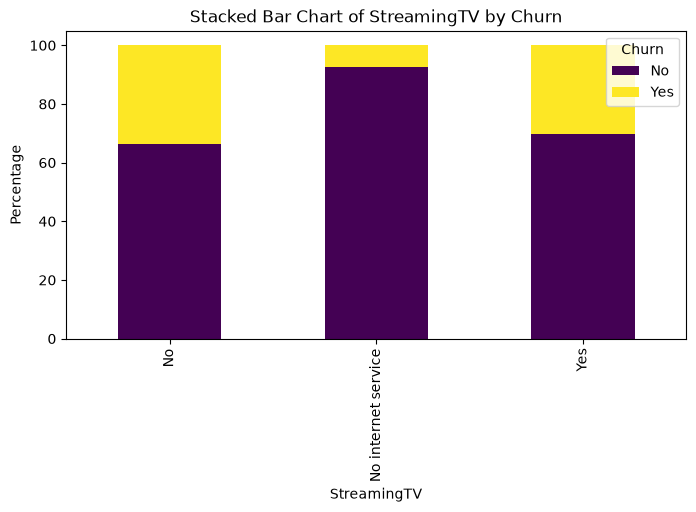

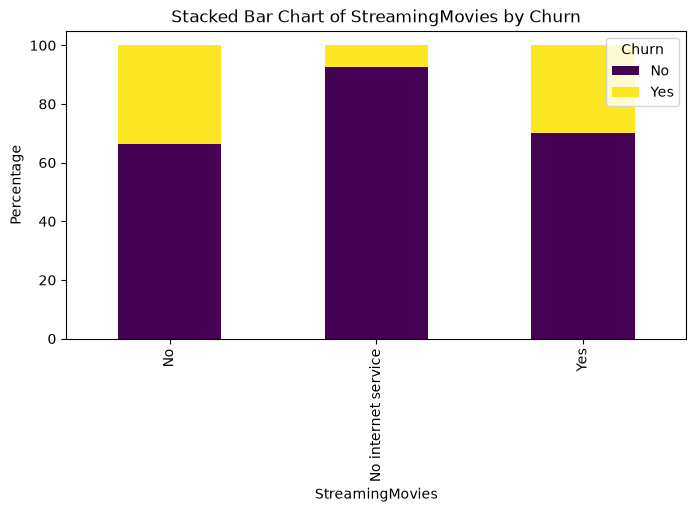

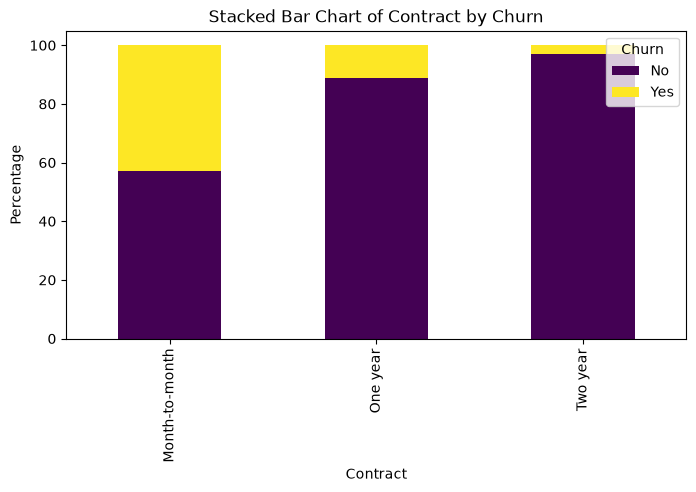

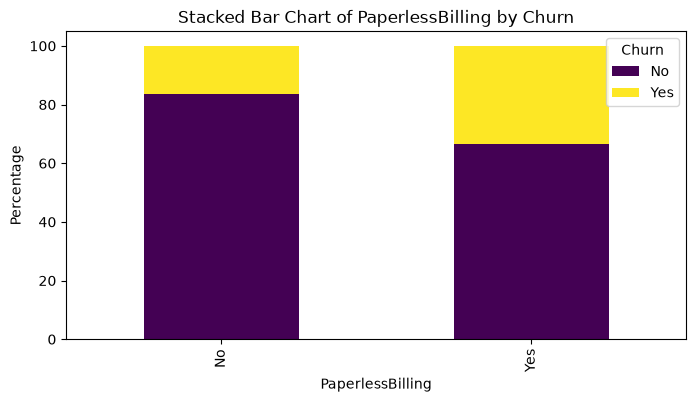

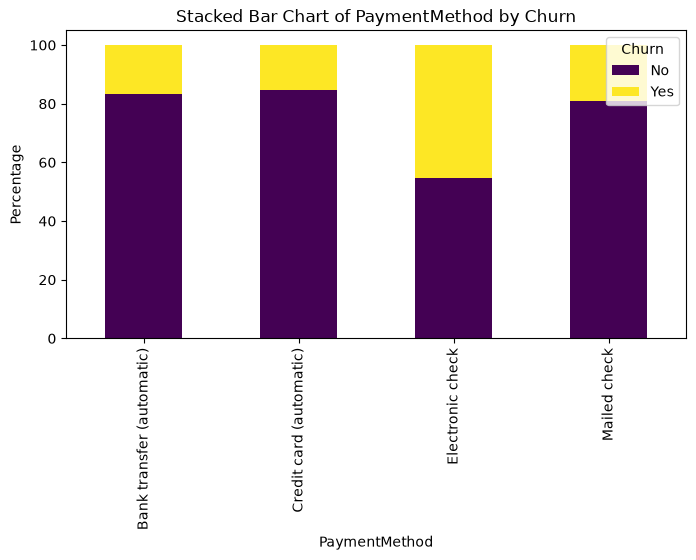

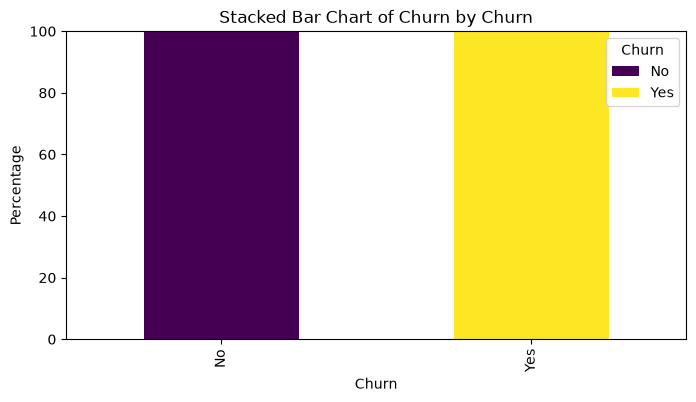

In [13]:
##stacked bar chart
for col in catcols:
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='viridis')
    plt.title(f'Stacked Bar Chart of {col} by Churn')
    plt.ylabel('Percentage')
    plt.xlabel(col)
    plt.legend(title='Churn', loc='upper right')
    plt.show()

## Feature Engineering

In [14]:
df["TechSupport"].value_counts( )

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [15]:
print(df["PaperlessBilling"].value_counts())
print(df["PaymentMethod"].value_counts())


PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [49]:
df = pd.read_csv('data/project2.csv')
df.drop(columns=['customerID'], inplace=True)

In [50]:
def engineer(df: pd.DataFrame) -> pd.DataFrame:

    # Has streaming
    df["Has_Streaming"] = (
        ((df["StreamingTV"] != "No") &
         (df["StreamingTV"] != "No internet service")) |
        ((df["StreamingMovies"] != "No") &
         (df["StreamingMovies"] != "No internet service"))
    ).astype(int)

    # df.drop(columns=["StreamingTV", "StreamingMovies"], inplace=True)

    # Has any online service
    df["Has_OnlineServices"] = (
        ((df["OnlineSecurity"] == "Yes") |
         (df["OnlineBackup"] == "Yes") |
         (df["DeviceProtection"] == "Yes") |
         (df["TechSupport"] == "Yes"))
    ).astype(int)

    # df.drop(
    #     columns=[
    #         "OnlineSecurity",
    #         "OnlineBackup",
    #         "DeviceProtection",
    #         "TechSupport",
    #     ],
    #     inplace=True,
    # )

    # # Has family
    df["Has_Family"] = (
        (df["Partner"] == "Yes") |
        (df["Dependents"] == "Yes")
    ).astype(int)

    return df

df = engineer(df)


# Training and Testing ML Models


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              7043 non-null   str    
 1   SeniorCitizen       7043 non-null   int64  
 2   Partner             7043 non-null   str    
 3   Dependents          7043 non-null   str    
 4   tenure              7043 non-null   int64  
 5   PhoneService        7043 non-null   str    
 6   MultipleLines       7043 non-null   str    
 7   InternetService     7043 non-null   str    
 8   OnlineSecurity      7043 non-null   str    
 9   OnlineBackup        7043 non-null   str    
 10  DeviceProtection    7043 non-null   str    
 11  TechSupport         7043 non-null   str    
 12  StreamingTV         7043 non-null   str    
 13  StreamingMovies     7043 non-null   str    
 14  Contract            7043 non-null   str    
 15  PaperlessBilling    7043 non-null   str    
 16  PaymentMethod    

In [82]:
x = df.drop(columns=["Churn", "Has_Family", "Has_Streaming", "Has_OnlineServices"])
y = df["Churn"]
print(x.shape)
print(y.shape)

(7043, 19)
(7043,)


In [84]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [85]:
x_num_cols = x.select_dtypes(include=np.number).columns.tolist()
x_cat_cols = x.select_dtypes(exclude=np.number).columns.tolist()

## Splitting into Train and Test Set

In [108]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training set shape:", x_train.shape, y_train.shape)
print("Testing set shape:", x_test.shape, y_test.shape)

Training set shape: (5634, 19) (5634,)
Testing set shape: (1409, 19) (1409,)


## Preprocessing x_train and x_test

In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), x_num_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), x_cat_cols)
    ],
    remainder='passthrough' # Keep other columns as they are
)

# Fit the preprocessor on x_train and transform x_train and x_test
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)



# Get feature names after one-hot encoding
# Adjusted to get feature names from the OneHotEncoder within the pipeline
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(x_cat_cols) if x_cat_cols else []
all_feature_names = (
    x_num_cols + list(cat_feature_names)
    if len(cat_feature_names) > 0
    else x_num_cols
)

# Convert the processed arrays back to DataFrames
x_train_processed_df = pd.DataFrame(x_train_processed, columns=all_feature_names, index=x_train.index) #type: ignore

# x_train_processed_df , y_train = over.fit_resample(x_train_processed_df, y_train)
x_train_processed_df.reset_index(drop=True, inplace=True)
y_train = y_train.reset_index(drop=True)

x_test_processed_df = pd.DataFrame(x_test_processed, columns=all_feature_names, index=x_test.index) #type: ignore

print("Shape of x_train_processed_df:", x_train_processed_df.shape)
print("Shape of x_test_processed_df:", x_test_processed_df.shape)
print("First 5 rows of x_train_processed_df:")
x_train_processed_df.head()

Shape of x_train_processed_df: (5634, 45)
Shape of x_test_processed_df: (1409, 45)
First 5 rows of x_train_processed_df:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.437749,-0.465683,-0.000474,-0.422105,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.437749,0.885537,1.074754,1.255360,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-0.437749,-1.284605,-1.376499,-1.002991,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.437749,-1.161766,0.177346,-0.908119,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.437749,-1.325551,-0.098524,0.000000,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [110]:
print(x_train.shape)
print(len(x_num_cols))
print(len(x_cat_cols))
print(preprocessor.get_feature_names_out().shape)

(5634, 19)
4
15
(45,)


In [111]:
type(x_train_processed_df), type(y_train), type(x_test_processed_df), type(y_test)

(pandas.DataFrame, pandas.Series, pandas.DataFrame, pandas.Series)

In [112]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_test = enc.transform(y_test)

y_train[:5], y_test[:5]


(array([0, 0, 1, 1, 0]), array([1, 0, 0, 1, 0]))

In [113]:
mapping = dict(zip(enc.classes_, range(len(enc.classes_))))
print(mapping)

yc = (y_train == 1).sum()
nc = (y_train == 0).sum()

print(f"Churned: {yc}")
print(f"Non-Churned: {nc}")

{'No': 0, 'Yes': 1}
Churned: 1496
Non-Churned: 4138


## Fitting multiple Models to find the best one

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss


# Initialize classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(learning_rate= 0.01,max_depth = 3,n_estimators = 1000),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
    # "SVM": SVC(random_state=42, probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

best_model = None
best_f1_score = -1
model_results = {}

for name, model in classifiers.items():
    print(f"\nTraining {name}...")
    model.fit(x_train_processed_df, y_train)
    y_pred = model.predict(x_test_processed_df)
    y_pred_proba = model.predict_proba(x_test_processed_df)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    lloss = log_loss(y_test, y_pred_proba)

    model_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "LogLoss": lloss
    }

    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, LogLoss: {lloss:.4f}")

    if f1 > best_f1_score:
        best_f1_score = f1
        best_model = model

print("\n--- Model Evaluation Results ---")
for name, metrics in model_results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

print(f"\nBest Model based on F1-Score: {best_model.__class__.__name__}")
print(f"Best F1-Score: {best_f1_score:.4f}")



Training Logistic Regression...
Logistic Regression - Accuracy: 0.8211, Precision: 0.6850, Recall: 0.6005, F1-Score: 0.6400, LogLoss: 0.3977

Training Decision Tree...
Decision Tree - Accuracy: 0.7154, Precision: 0.4641, Recall: 0.4853, F1-Score: 0.4744, LogLoss: 10.2342

Training Random Forest...
Random Forest - Accuracy: 0.7956, Precision: 0.6604, Recall: 0.4692, F1-Score: 0.5486, LogLoss: 0.4974

Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.8077, Precision: 0.6747, Recall: 0.5282, F1-Score: 0.5925, LogLoss: 0.3984

Training XGBoost...
XGBoost - Accuracy: 0.8084, Precision: 0.6746, Recall: 0.5335, F1-Score: 0.5958, LogLoss: 0.3974

Training CatBoost...
CatBoost - Accuracy: 0.8006, Precision: 0.6533, Recall: 0.5255, F1-Score: 0.5825, LogLoss: 0.4033

Training K-Nearest Neighbors...
K-Nearest Neighbors - Accuracy: 0.7743, Precision: 0.5770, Recall: 0.5523, F1-Score: 0.5644, LogLoss: 1.3924

--- Model Evaluation Results ---

Logistic Regression:
  Accuracy: 0.8211
  Pr

Best Model based on F1-Score: LogisticRegression
Best F1-Score: 0.5585  

Best Model based on F1-Score: CatBoostClassifier
Best F1-Score: 0.5620 (dropped ["InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"])  

Best Model based on F1-Score: GradientBoostingClassifier
Best F1-Score: 0.6585 (after feature engineering and oversampling)  

Best Model based on F1-Score: LogisticRegression
Best F1-Score: 0.6263 (after feature engineering but no oversampling)

Best Model based on F1-Score: LogisticRegression
Best F1-Score: 0.6400 (after dropping added features)

<Axes: >

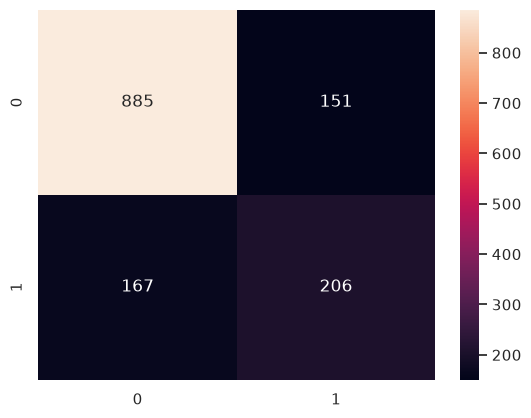

In [115]:
#print heatmap of confusion matrix for best model
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')


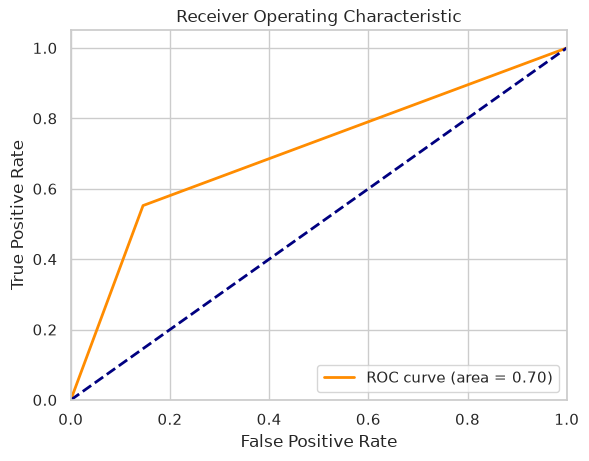

In [116]:
#roc curve for best model


import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

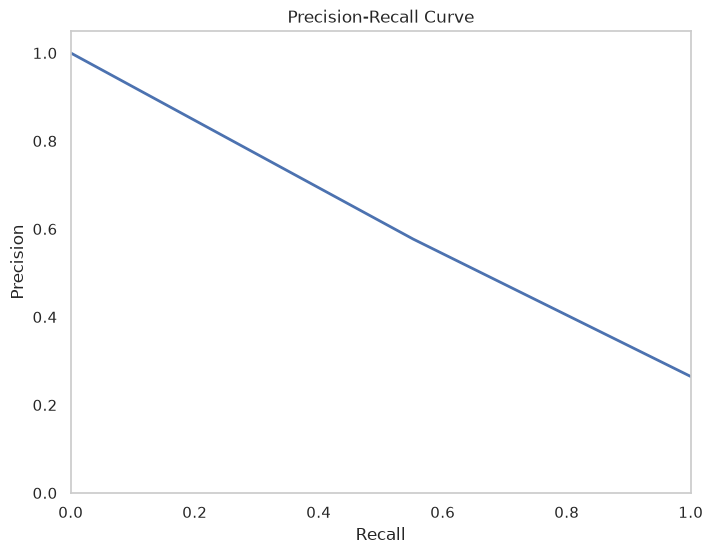

In [117]:
#precision-recall curve for best model

from sklearn.metrics import precision_recall_curve


precision, recall, _ = precision_recall_curve(y_test, y_pred)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid()

In [118]:
# feature_names = preprocessor.get_feature_names_out()

importance = (
    best_model.coef_.ravel() # type: ignore
    if hasattr(best_model, "coef_")
    else best_model.feature_importances_ # type: ignore
)

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importance
})

top20 = (
    feature_importance
    .assign(AbsImportance=lambda df: df["Importance"].abs())
    .sort_values("AbsImportance", ascending=False)
    #.head(20)
)

print(top20[["Feature", "Importance"]])

                                    Feature  Importance
1                                    tenure   -1.313264
38                        Contract_Two year   -0.847051
3                              TotalCharges    0.610684
36                  Contract_Month-to-month    0.586955
15                      InternetService_DSL   -0.550558
16              InternetService_Fiber optic    0.474766
2                            MonthlyCharges   -0.349682
39                      PaperlessBilling_No   -0.329431
12                         MultipleLines_No   -0.279508
11                         PhoneService_Yes   -0.262457
34      StreamingMovies_No internet service   -0.249722
17                       InternetService_No   -0.249722
19       OnlineSecurity_No internet service   -0.249722
25     DeviceProtection_No internet service   -0.249722
28          TechSupport_No internet service   -0.249722
22         OnlineBackup_No internet service   -0.249722
31          StreamingTV_No internet service   -0

In [119]:
import pickle as pkl

with open("best_model_project_2.pkl", "wb") as f:
    pkl.dump(best_model, f)

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    "C": loguniform(1e-4, 1e2),
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"],
    "max_iter": [500, 1000, 2000]
}

random_search = RandomizedSearchCV(
    estimator=best_model, # type: ignore
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(x_train_processed_df, y_train)

best_model_tuned = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print(f"\nBest CV F1: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END C=0.017670169402947963, class_weight=None, max_iter=2000, solver=liblinear; total time=   0.0s
[CV] END C=0.017670169402947963, class_weight=None, max_iter=2000, solver=liblinear; total time=   0.1s
[CV] END C=0.017670169402947963, class_weight=None, max_iter=2000, solver=liblinear; total time=   0.1s
[CV] END C=0.017670169402947963, class_weight=None, max_iter=2000, solver=liblinear; total time=   0.1s
[CV] END C=0.017670169402947963, class_weight=None, max_iter=2000, solver=liblinear; total time=   0.1s
[CV] END C=0.0008632008168602544, class_weight=None, max_iter=2000, solver=liblinear; total time=   0.0s
[CV] END C=0.0008632008168602544, class_weight=None, max_iter=2000, solver=liblinear; total time=   0.0s
[CV] END C=2.465832945854912, class_weight=None, max_iter=500, solver=liblinear; total time=   0.1s
[CV] END C=0.0008632008168602544, class_weight=None, max_iter=2000, solver=liblinear; total time=   0.0s
[CV

In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)

y_pred = best_model.predict(x_test_processed_df)
y_pred_proba = best_model.predict_proba(x_test_processed_df)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"Log Loss : {log_loss(y_test, y_pred_proba):.4f}")

Accuracy : 0.8211
Precision: 0.6850
Recall   : 0.6005
F1 Score : 0.6400
Log Loss : 0.3977


In [123]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)

y_pred = best_model_tuned.predict(x_test_processed_df)
y_pred_proba = best_model_tuned.predict_proba(x_test_processed_df)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"Log Loss : {log_loss(y_test, y_pred_proba):.4f}")

Accuracy : 0.7587
Precision: 0.5283
Recall   : 0.8257
F1 Score : 0.6444
Log Loss : 0.4779
